# Route-Conditioned Repetition Lag-CRP

> Examine transitions through a repeated item after recall enters from one occurrence's neighborhood.

The route-conditioned repetition CRP analysis examines triples of the form neighbor $\rightarrow$ repeater $\rightarrow$ next recall. For a repeated item at positions $i$ and $j$, the analysis tracks whether recall enters the repeated item from $i$'s forward neighbors or $j$'s forward neighbors, then scores the following recall as a lag from either occurrence.

These route-conditioned transitions test whether a repeated item preserves the incoming occurrence route, switches to the other occurrence's neighborhood, or behaves like a route-erasing item cue.

## Workflow

In [1]:
import os

import matplotlib.pyplot as plt

from jaxcmr.analyses.reproutecrp import (
    plot_rep_route_crp,
    subject_rep_route_crp,
    test_rep_route_crp_vs_control,
    test_same_switch_bias,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure
from jaxcmr.repetition import make_control_dataset

In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = [0, .50]
mixed_trial_query = "data['list_type'] > 3"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 10
min_lag = 4
max_lag = 3
use_lag2 = True
directions = ["i2i", "i2j", "j2i", "j2j", "same", "switch"]

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(data, mixed_trial_query, control_trial_query, control_shuffles)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)
datasets = [data, control_dataset]
masks = [trial_mask, control_mask]

/Users/jordangunn/workspace/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:365: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


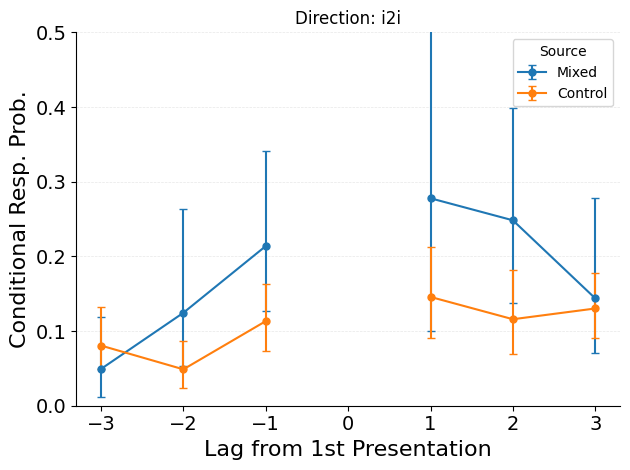

/Users/jordangunn/workspace/.venv/lib/python3.12/site-packages/scipy/stats/_resampling.py:155: RuntimeWarning: invalid value encountered in divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)


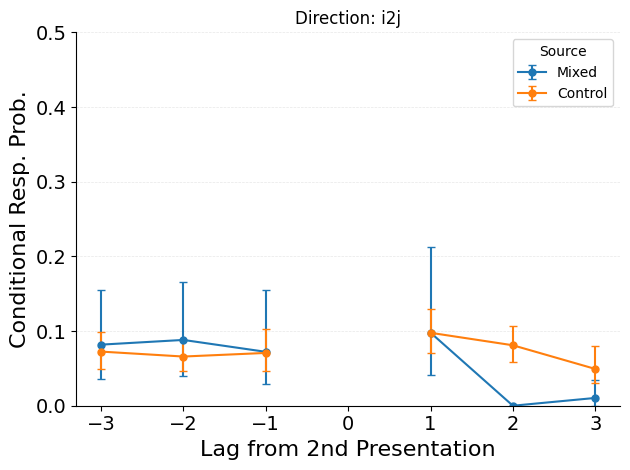

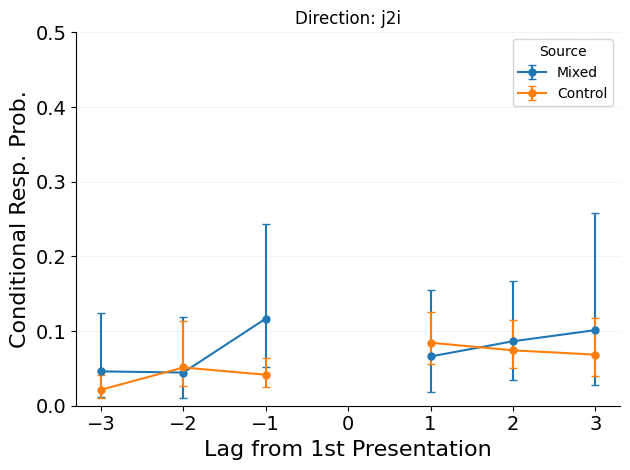

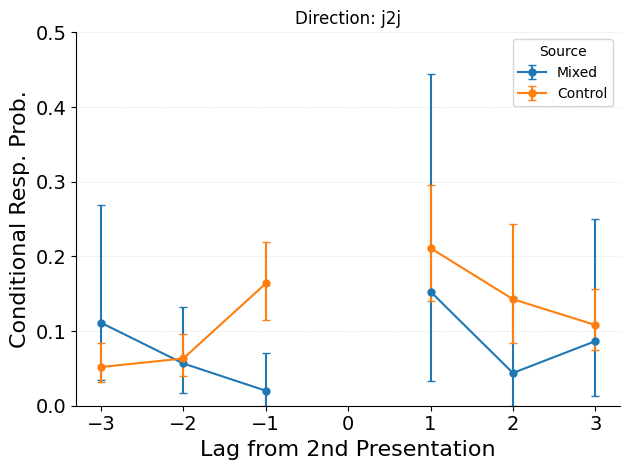

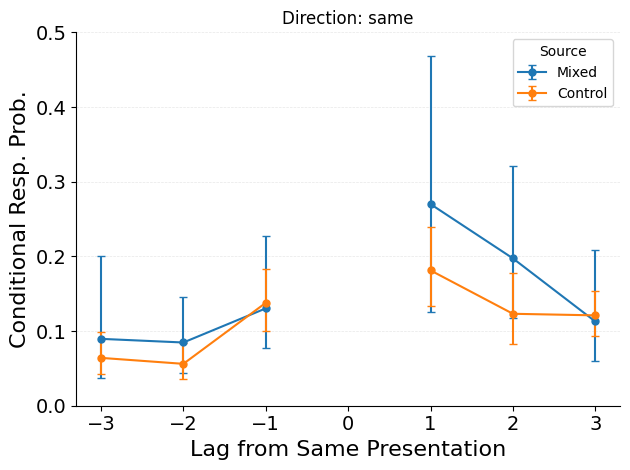

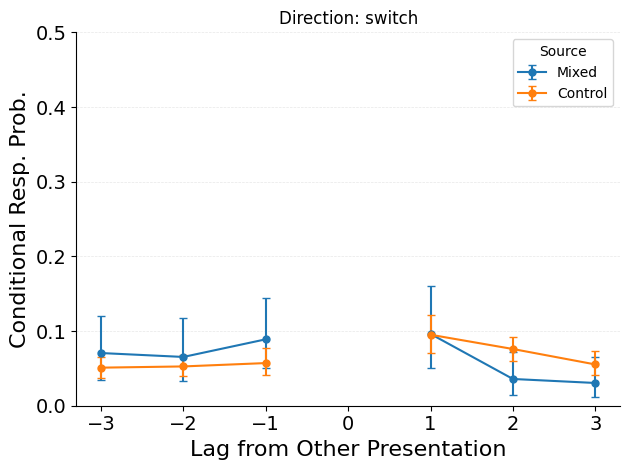

In [4]:
for direction in directions:
    plot_rep_route_crp(
        datasets=datasets,
        trial_masks=masks,
        max_lag=max_lag,
        min_lag=min_lag,
        direction=direction,
        use_lag2=use_lag2,
        contrast_name="Source",
        labels=["Mixed", "Control"],
    )
    plt.title(f"Direction: {direction}")
    if ylim is not None:
        for ax in plt.gcf().axes:
            ax.set_ylim(ylim)
    save_figure(figure_dir, figure_str, suffix=direction)

In [5]:
for direction in directions:
    observed_crp = subject_rep_route_crp(
        data, trial_mask, direction, use_lag2, min_lag, max_lag
    )
    control_crp = subject_rep_route_crp(
        control_dataset, control_mask, direction, use_lag2, min_lag, max_lag
    )

    result = test_rep_route_crp_vs_control(observed_crp, control_crp, max_lag, direction)

    print(f"\n{'='*70}")
    print(f"Statistical Test: {direction}")
    print(f"{'='*70}")
    if direction == "same":
        print("Tests whether same-route continuations through the repeater are elevated vs control.")
    elif direction == "switch":
        print("Tests whether switch-route continuations through the repeater are elevated vs control.")
    else:
        print("Tests one incoming-route/outgoing-center combination vs control.")
    print()
    print(result)

observed_same = subject_rep_route_crp(
    data, trial_mask, "same", use_lag2, min_lag, max_lag
)
observed_switch = subject_rep_route_crp(
    data, trial_mask, "switch", use_lag2, min_lag, max_lag
)
control_same = subject_rep_route_crp(
    control_dataset, control_mask, "same", use_lag2, min_lag, max_lag
)
control_switch = subject_rep_route_crp(
    control_dataset, control_mask, "switch", use_lag2, min_lag, max_lag
)
bias_result = test_same_switch_bias(
    observed_same, observed_switch, control_same, control_switch, max_lag
)

print(f"\n{'='*70}")
print("Test: Same-Switch Bias (Observed) vs Same-Switch Bias (Control)")
print(f"{'='*70}")
print(bias_result)

/Users/jordangunn/workspace/jaxcmr/jaxcmr/analyses/reproutecrp.py:714: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_col, ctrl_col, nan_policy="omit")
/Users/jordangunn/workspace/jaxcmr/jaxcmr/analyses/reproutecrp.py:725: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff)



Statistical Test: i2i
Tests one incoming-route/outgoing-center combination vs control.

Direction: i2i
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -3 |   -0.850     0.4022 |     44.0     0.3634 |    -0.0266
   -2 |    1.420     0.1661 |     56.0     0.3310 |     0.0771
   -1 |    2.231     0.0339 |     57.0     0.0419 |     0.1234
    0 |      nan        nan |      nan        nan |        nan
    1 |    0.918     0.3717 |     28.5     0.4096 |     0.1039
    2 |    1.893     0.0687 |     43.5     0.1182 |     0.1200
    3 |    0.126     0.9007 |     75.0     0.6474 |     0.0054

Statistical Test: i2j
Tests one incoming-route/outgoing-center combination vs control.

Direction: i2j
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -3 |    0.198     0.8443 |    103.0     0.6637 |     0.0069
   -2 |    0.706     0.4854 | 

## Interpretation

Plots show transition probabilities after recall reaches a repeated item from a nearby occurrence-specific route. Key patterns:

- **Route preservation**: elevated same-route continuations indicate that recall of the repeated item preserves the incoming occurrence route.
- **Route switching**: elevated switch-route continuations indicate that the repeated item acts as a bridge into the other occurrence's neighborhood.
- **Observed vs. control**: differences isolate repetition-specific route effects beyond shuffled baselines.
- **Same-switch bias**: a positive same-switch difference suggests that the repeated item is not simply erasing the incoming route.

## API Details

### Notebook parameters

- `data_path` - path to an HDF5 file containing a `RecallDataset` with repeated items.
- `figure_dir` - directory for saving figures.
- `figure_str` - base filename for saved figures. Leave empty to display without saving.
- `ylim` - y-axis limits as a tuple, or `None` for automatic scaling.
- `mixed_trial_query` - selects trials containing repeated items.
- `control_trial_query` - selects pure control trials for the shuffled control.
- `control_shuffles` - number of shuffled control blocks per subject.
- `min_lag` - minimum spacing between repeated presentations.
- `max_lag` - maximum lag to display on the x-axis.
- `use_lag2` - whether incoming routes include +2 neighbors as well as +1 neighbors.
- `directions` - route-conditioned transitions to plot and test.

### Directions

- `i2i` - i-neighbor -> repeater -> lags centered on i.
- `i2j` - i-neighbor -> repeater -> lags centered on j.
- `j2i` - j-neighbor -> repeater -> lags centered on i.
- `j2j` - j-neighbor -> repeater -> lags centered on j.
- `same` - count-combined i2i and j2j.
- `switch` - count-combined i2j and j2i.
- `both` - full 2 x 2 route matrix.